# Análisis Exploratorio de Datos (EDA) y Preprocesamiento

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats


In [2]:
# data_test = pd.read_csv('data/blood_samples_dataset_test.csv')
df = pd.read_csv('data/Blood_samples_dataset_balanced_2(f).csv')

# Ver las columnas del dataset
print(df.shape)
print(df.head())

(2351, 25)
    Glucose  Cholesterol  Hemoglobin  Platelets  White Blood Cells  \
0  0.739597     0.650198    0.713631   0.868491           0.687433   
1  0.121786     0.023058    0.944893   0.905372           0.507711   
2  0.452539     0.116135    0.544560   0.400640           0.294538   
3  0.136609     0.015605    0.419957   0.191487           0.081168   
4  0.176737     0.752220    0.971779   0.785286           0.443880   

   Red Blood Cells  Hematocrit  Mean Corpuscular Volume  \
0         0.529895    0.290006                 0.631045   
1         0.403033    0.164216                 0.307553   
2         0.382021    0.625267                 0.295122   
3         0.166214    0.073293                 0.668719   
4         0.439851    0.894991                 0.442159   

   Mean Corpuscular Hemoglobin  Mean Corpuscular Hemoglobin Concentration  \
0                     0.001328                                   0.795829   
1                     0.207938                             

In [3]:
# Ver las categorías de la columna 'Disease'
print(df['Disease'].value_counts())

Disease
Anemia      623
Healthy     556
Diabetes    540
Thalasse    509
Thromboc    123
Name: count, dtype: int64


In [4]:
# Cambiar de ingles a esañol las enfermedades
df['Disease'] = df['Disease'].replace({
    'Anemia': 'Anemia',
    'Diabetes': 'Diabetes',
    'Healthy': 'Sano',
    'Thalasse': 'Talasemia',
    'Thromboc': 'Trombocitopenia'
})

============= DISTRIBUCIÓN DE CLASES =============
     Enfermedad  Conteo  Porcentaje
         Anemia     623       26.50
           Sano     556       23.65
       Diabetes     540       22.97
      Talasemia     509       21.65
Trombocitopenia     123        5.23
Total de registros: 2,351
Clases: 5


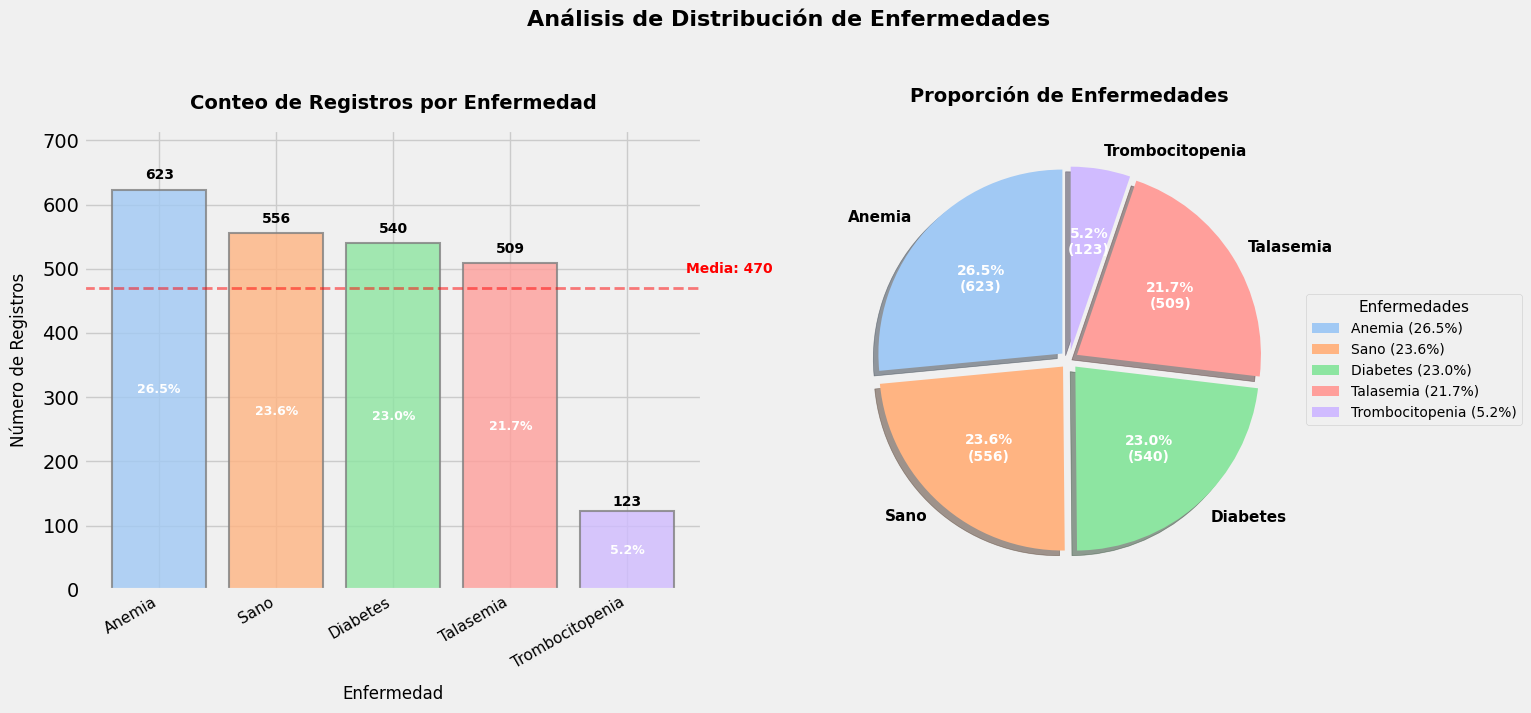

In [5]:
features = df.drop(columns=["Disease"])
target   = df["Disease"]
# =============================================================================
# 1. DISTRIBUCIÓN DE CLASES
# =============================================================================

# Configuración global de estilo
plt.style.use('fivethirtyeight') # Otro estilo limpio a seaborn-v0_8-whitegrid puedes probar 'ggplot', 'seaborn-darkgrid', 'fivethirtyeight', etc.
sns.set_palette("pastel") # Paleta de colores suave y profesional o sns.set_palette("pastel") para colores más suaves

# Calcular distribuciones
class_counts = target.value_counts()
class_pct = target.value_counts(normalize=True) * 100
n_classes = len(class_counts)

# Crear dataframe de resumen
summary_df = pd.DataFrame({
    'Enfermedad': class_counts.index,
    'Conteo': class_counts.values,
    'Porcentaje': class_pct.values.round(2)
})

print("=" * 50)
print(" DISTRIBUCIÓN DE CLASES ".center(50, "="))
print("=" * 50)
print(summary_df.to_string(index=False))
print(f"Total de registros: {class_counts.sum():,}")
print(f"Clases: {n_classes}")

# Crear figura mejorada
fig = plt.figure(figsize=(16, 7))
fig.suptitle('Análisis de Distribución de Enfermedades', fontsize=16, fontweight='bold', y=1.02)

# Definir colores consistentes
colors = sns.color_palette("pastel", n_classes)

# 1. GRÁFICO DE BARRAS MEJORADO
ax1 = plt.subplot(1, 2, 1)
bars = ax1.bar(range(n_classes), class_counts.values, color=colors, 
               edgecolor='gray', linewidth=1.5, alpha=0.8)

# Personalizar barras
ax1.set_title('Conteo de Registros por Enfermedad', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Enfermedad', fontsize=12, labelpad=10)
ax1.set_ylabel('Número de Registros', fontsize=12, labelpad=10)
ax1.set_xticks(range(n_classes))
ax1.set_xticklabels(class_counts.index, rotation=30, ha='right', fontsize=11)

# Añadir etiquetas de valor y porcentaje en las barras
for i, (bar, (count, pct)) in enumerate(zip(bars, zip(class_counts.values, class_pct.values))):
    height = bar.get_height()
    # Valor absoluto
    ax1.text(bar.get_x() + bar.get_width()/2, height + (height*0.02),
             f'{int(count):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    # Porcentaje
    ax1.text(bar.get_x() + bar.get_width()/2, height/2,
             f'{pct:.1f}%', ha='center', va='center', fontsize=9, 
             color='white', fontweight='bold')

# Añadir línea de tendencia (media)
mean_count = class_counts.mean()
ax1.axhline(y=mean_count, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax1.text(len(class_counts)-0.5, mean_count + (mean_count*0.05), 
         f'Media: {mean_count:.0f}', color='red', fontsize=10, fontweight='bold')

# Ajustar límites del eje y
ax1.set_ylim(0, class_counts.max() * 1.15)

# 2. GRÁFICO DE PASTEL MEJORADO
ax2 = plt.subplot(1, 2, 2)

# Función para autopct personalizado
def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{pct:.1f}%\n({absolute:,})"

# Crear pie chart mejorado
wedges, texts, autotexts = ax2.pie(class_counts.values, 
                                    labels=class_counts.index,
                                    autopct=lambda pct: func(pct, class_counts.values),
                                    colors=colors,
                                    startangle=90,
                                    explode=[0.05] * n_classes,  # Ligera separación
                                    shadow=True,
                                    textprops={'fontsize': 11})

# Mejorar etiquetas
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax2.set_title('Proporción de Enfermedades', fontsize=14, fontweight='bold', pad=20)

# Añadir leyenda con información adicional
ax2.legend(wedges, [f'{label} ({pct:.1f}%)' for label, pct in zip(class_counts.index, class_pct.values)],
           title="Enfermedades", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1),
           fontsize=10, title_fontsize=11)

# Ajustar layout
plt.tight_layout()

# Guardar figura de alta calidad
plt.savefig("img/1_distribucion_clases_mejorada.png", dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()




======= TOP 15 PARES CON MAYOR CORRELACIÓN =======
       Variable_1                  Variable_2  Correlacion
          Glucose                         BMI     0.362967
       Hemoglobin             LDL Cholesterol     0.302901
              BMI    Diastolic Blood Pressure     0.300301
      Cholesterol Mean Corpuscular Hemoglobin    -0.299422
  HDL Cholesterol          C-reactive Protein    -0.262912
          Insulin                         ALT     0.254003
  Red Blood Cells             HDL Cholesterol     0.252507
White Blood Cells                  Hematocrit     0.249787
            HbA1c                    Troponin     0.248086
              BMI                         AST    -0.247911
          Insulin                         AST     0.247473
              BMI                  Creatinine    -0.242802
        Platelets               Triglycerides    -0.242272
  HDL Cholesterol                    Troponin    -0.236338
    Triglycerides             LDL Cholesterol     0.235197


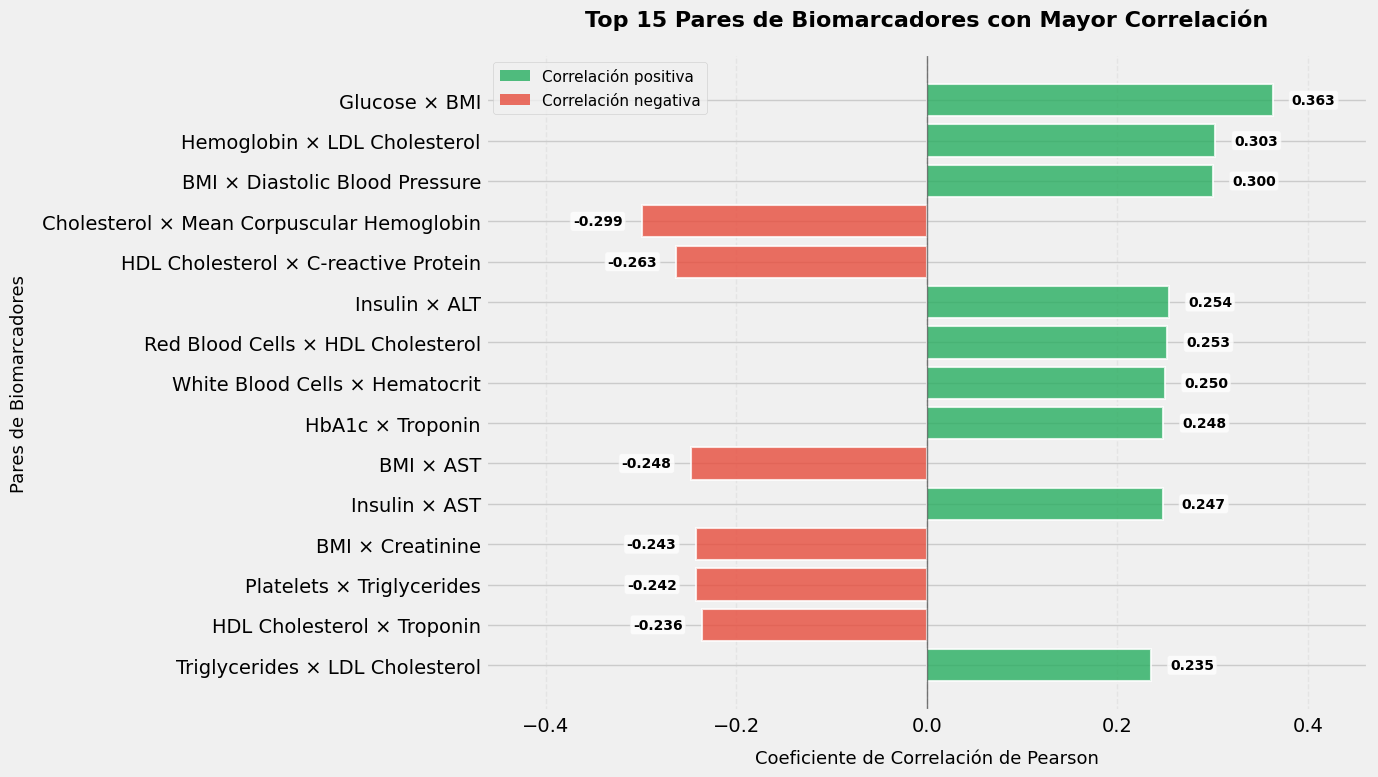


Estadísticas de Correlación:
   • Correlación máxima positiva: 0.363
   • Correlación máxima negativa: -0.299
   • Media de correlaciones: 0.061
   • Correlaciones > 0.5: 0 pares


In [6]:
# =============================================================================
# 2. CORRELACIÓN DE BIOMARCADORES - VERSIÓN CORREGIDA
# =============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Calcular matriz de correlación
corr_matrix = features.corr()

# Top pares con mayor correlación absoluta
corr_pairs = (corr_matrix
              .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
              .stack()
              .reset_index())
corr_pairs.columns = ["Variable_1", "Variable_2", "Correlacion"]
corr_pairs["Abs"] = corr_pairs["Correlacion"].abs()
top_corr = corr_pairs.sort_values("Abs", ascending=False).head(15)

print("\n" + "="*50)
print(" TOP 15 PARES CON MAYOR CORRELACIÓN ".center(50, "="))
print("="*50)
print(top_corr[["Variable_1", "Variable_2", "Correlacion"]].to_string(index=False))

# Crear figura con un solo gráfico
fig, ax = plt.subplots(figsize=(14, 8))

# Colores: rojo para correlaciones negativas, verde para positivas
colors = ["#e74c3c" if v < 0 else "#27ae60" for v in top_corr["Correlacion"]]

# Crear etiquetas combinadas
labels = top_corr["Variable_1"] + " × " + top_corr["Variable_2"]

# Gráfico de barras horizontales
bars = ax.barh(labels, top_corr["Correlacion"], color=colors, edgecolor="white", linewidth=1.5, alpha=0.8)

# Línea vertical en cero
ax.axvline(0, color="black", linewidth=1, linestyle='-', alpha=0.5)

# Personalizar el gráfico
ax.set_title("Top 15 Pares de Biomarcadores con Mayor Correlación", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Coeficiente de Correlación de Pearson", fontsize=13, labelpad=10)
ax.set_ylabel("Pares de Biomarcadores", fontsize=13, labelpad=10)
ax.invert_yaxis()  # Para que el mayor esté arriba

# Añadir etiquetas de valor en las barras
for i, (bar, v) in enumerate(zip(bars, top_corr["Correlacion"])):
    # Posicionar etiqueta
    if v >= 0:
        x_pos = v + 0.02
        ha = 'left'
    else:
        x_pos = v - 0.02
        ha = 'right'
    
    ax.text(x_pos, i, f"{v:.3f}", 
            va='center', ha=ha, fontsize=10, fontweight='bold',
            color='black', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# Añadir líneas de referencia
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axvline(x=-0.5, color='gray', linestyle='--', alpha=0.3, linewidth=1)

# Ajustar límites del eje x
max_abs = max(abs(top_corr["Correlacion"]))
ax.set_xlim(-max_abs - 0.1, max_abs + 0.1)

# Añadir grid para mejor legibilidad
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#27ae60', alpha=0.8, label='Correlación positiva'),
                   Patch(facecolor='#e74c3c', alpha=0.8, label='Correlación negativa')]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)

# Ajustar layout
plt.tight_layout()

# Guardar figura
plt.savefig("img/2_correlacion_biomarkers_mejorada.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Mostrar estadísticas adicionales
print("\nEstadísticas de Correlación:")
print(f"   • Correlación máxima positiva: {top_corr['Correlacion'].max():.3f}")
print(f"   • Correlación máxima negativa: {top_corr['Correlacion'].min():.3f}")
print(f"   • Media de correlaciones: {top_corr['Correlacion'].mean():.3f}")
print(f"   • Correlaciones > 0.5: {(abs(top_corr['Correlacion']) > 0.5).sum()} pares")


============= RESUMEN DE OUTLIERS POR VARIABLE =============
                                              Q1     Q3    IQR  Lower  Upper  N_outliers  Pct
Glucose                                    0.129  0.582  0.453 -0.550  1.262         0.0  0.0
Cholesterol                                0.196  0.582  0.386 -0.384  1.162         0.0  0.0
Troponin                                   0.289  0.682  0.393 -0.301  1.272         0.0  0.0
Creatinine                                 0.213  0.607  0.394 -0.378  1.197         0.0  0.0
Heart Rate                                 0.339  0.801  0.462 -0.353  1.493         0.0  0.0
AST                                        0.240  0.616  0.377 -0.325  1.181         0.0  0.0
ALT                                        0.211  0.710  0.499 -0.538  1.459         0.0  0.0
HDL Cholesterol                            0.307  0.779  0.472 -0.401  1.488         0.0  0.0
LDL Cholesterol                            0.218  0.605  0.387 -0.363  1.185         0.0  0.

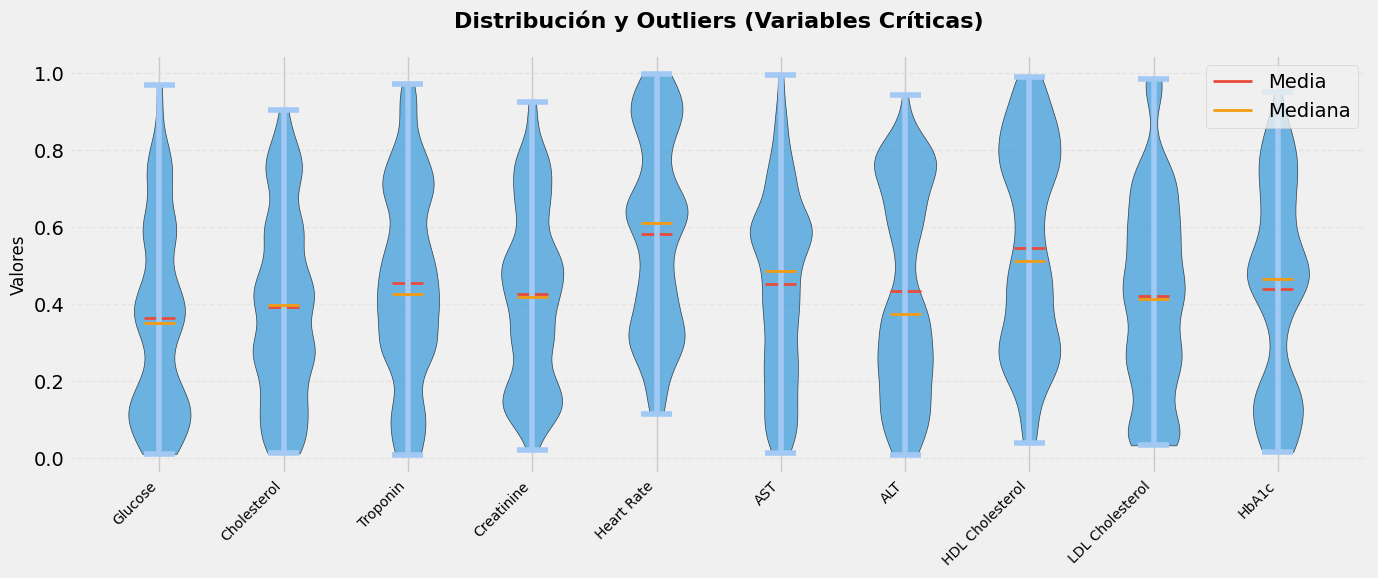

In [ ]:
# =============================================================================
# 3. DETECCIÓN DE OUTLIERS (IQR) - VERSIÓN MEJORADA
# =============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

def detectar_outliers_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    outliers = serie[(serie < lower) | (serie > upper)]
    return {"Q1": Q1, "Q3": Q3, "IQR": IQR,
            "Lower": lower, "Upper": upper,
            "N_outliers": len(outliers), "Pct": len(outliers)/len(serie)*100}

# Resumen tabular
outlier_summary = pd.DataFrame({col: detectar_outliers_iqr(features[col])
                                 for col in features.columns}).T
outlier_summary = outlier_summary.sort_values("N_outliers", ascending=False)

print("\n" + "="*60)
print(" RESUMEN DE OUTLIERS POR VARIABLE ".center(60, "="))
print("="*60)
print(outlier_summary[["Q1","Q3","IQR","Lower","Upper","N_outliers","Pct"]].round(3).to_string())

# Variables críticas (>5% de outliers)
criticas = outlier_summary[outlier_summary["Pct"] > 5]
if not criticas.empty:
    print("\n" + "!"*60)
    print("VARIABLES CRÍTICAS (>5% OUTLIERS) ⚠".center(60, " "))
    print("!"*60)
    print(criticas[["N_outliers", "Pct"]].round(2).to_string())
    print(f"\nTotal variables críticas: {len(criticas)} de {len(features.columns)}")



# =============================================================================
# VISUALIZACIÓN 4: Diagrama de violín (alternativa al boxplot)
# =============================================================================
# Seleccionar un subconjunto de variables para el diagrama de violín
# (mostrar todas sería demasiado, así que mostramos las más críticas)
top_vars = criticas.index.tolist() if len(criticas) > 0 else outlier_summary.head(10).index.tolist()

if len(top_vars) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Preparar datos para violín plot
    data_violin = [features[var].dropna().values for var in top_vars]
    
    # Crear violín plot
    parts = ax.violinplot(data_violin, positions=range(len(top_vars)), 
                          showmeans=True, showmedians=True)
    
    # Personalizar colores
    for pc in parts['bodies']:
        pc.set_facecolor('#3498db')
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
    
    parts['cmeans'].set_color('#e74c3c')
    parts['cmeans'].set_linewidth(2)
    parts['cmedians'].set_color('#f39c12')
    parts['cmedians'].set_linewidth(2)
    
    # Personalizar ejes
    ax.set_xticks(range(len(top_vars)))
    ax.set_xticklabels(top_vars, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Valores', fontsize=12)
    ax.set_title('Distribución y Outliers (Variables Críticas)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Leyenda
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color='#e74c3c', lw=2, label='Media'),
                       Line2D([0], [0], color='#f39c12', lw=2, label='Mediana')]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.savefig("img/3_outliers_violinplot.png", dpi=300, bbox_inches="tight")
    plt.show()
